# 1️⃣ Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv")
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,T7496,U6242,3962.99,Payment,Card,Web,Delhi,1917,14,0,24820.55,0,0.926,9,0
7496,T7497,U6299,3675.11,Transfer,Card,Web,Hyderabad,329,0,4,6208.20,0,0.036,5,0
7497,T7498,U6605,42523.37,Withdrawal,NetBanking,Android,Chennai,67,19,1,27344.69,0,0.149,6,0
7498,T7499,U5956,10681.86,Withdrawal,UPI,Web,Hyderabad,282,15,2,26586.50,0,0.198,2,0


In [3]:
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [4]:
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 14  fraud_la

In [6]:
df.isnull().sum()

transaction_id              0
user_id                     0
transaction_amount          0
transaction_type            0
payment_mode                0
device_type                 0
device_location             0
account_age_days            0
transaction_hour            0
previous_failed_attempts    0
avg_transaction_amount      0
is_international            0
ip_risk_score               0
login_attempts_last_24h     0
fraud_label                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='fraud_label', ylabel='count'>

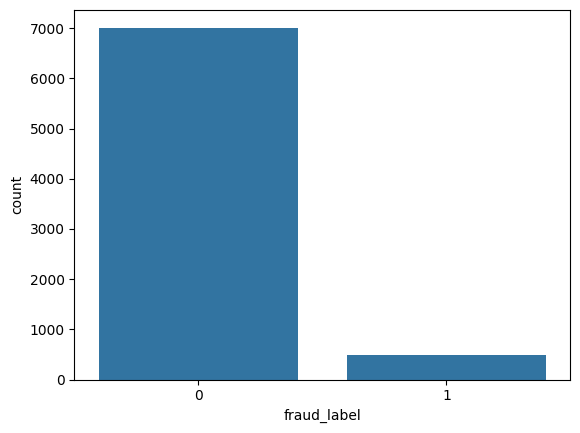

In [8]:
sns.countplot(x="fraud_label",data=df)

In [9]:
df['fraud_label'].value_counts()

fraud_label
0    7011
1     489
Name: count, dtype: int64

In [10]:
le=LabelEncoder()

In [11]:
categorical_columns=['transaction_type','payment_mode','device_type','device_location']
le_dict={}
for col in categorical_columns:
    df[col]=le.fit_transform(df[col])
    le_dict[col]=le
df  

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,1,2,1,3,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,0,3,2,3,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,0,0,0,1,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,0,3,2,1,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,0,2,1,2,301,4,1,9317.49,1,0.468,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,T7496,U6242,3962.99,0,0,1,2,1917,14,0,24820.55,0,0.926,9,0
7496,T7497,U6299,3675.11,1,0,1,3,329,0,4,6208.20,0,0.036,5,0
7497,T7498,U6605,42523.37,2,1,0,1,67,19,1,27344.69,0,0.149,6,0
7498,T7499,U5956,10681.86,2,2,1,3,282,15,2,26586.50,0,0.198,2,0


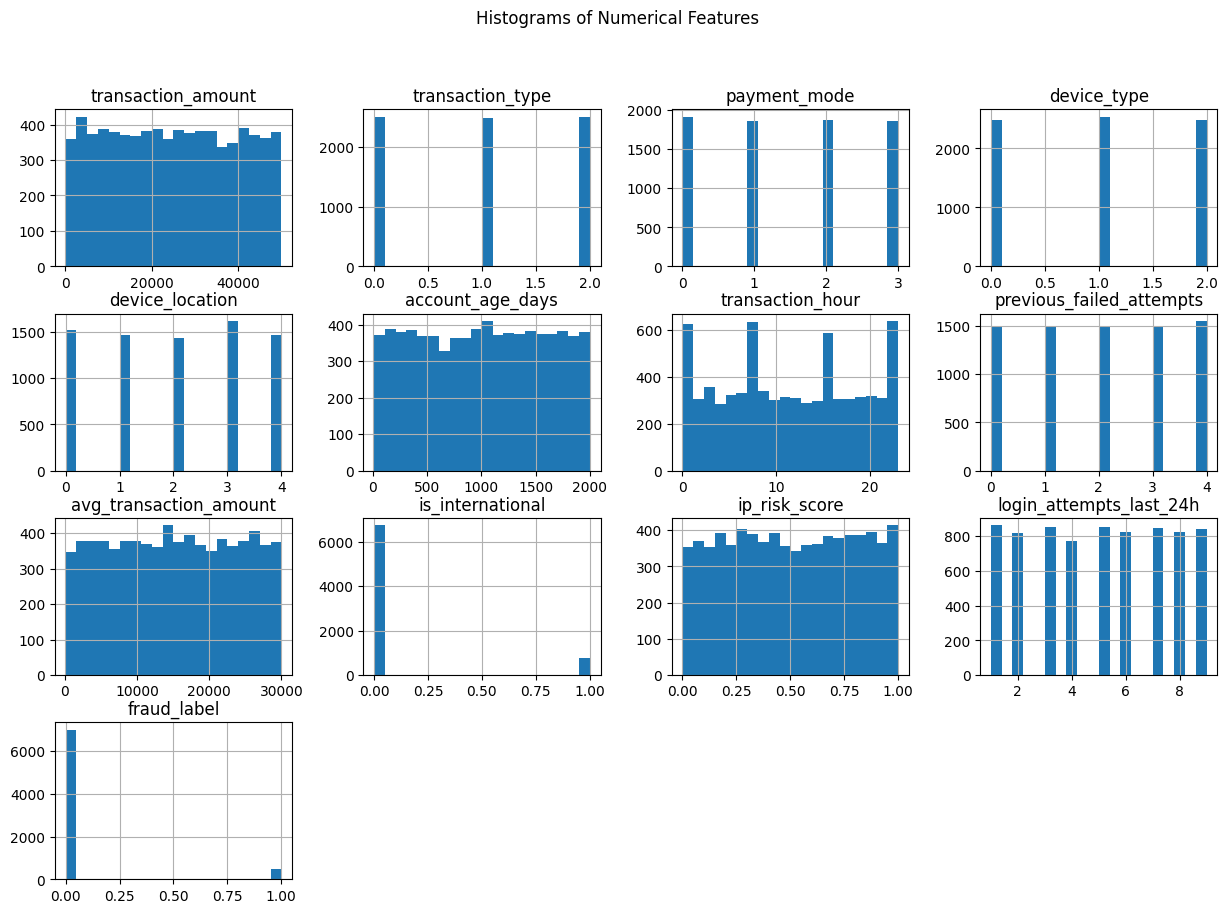

In [12]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col != 'target'] 
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()

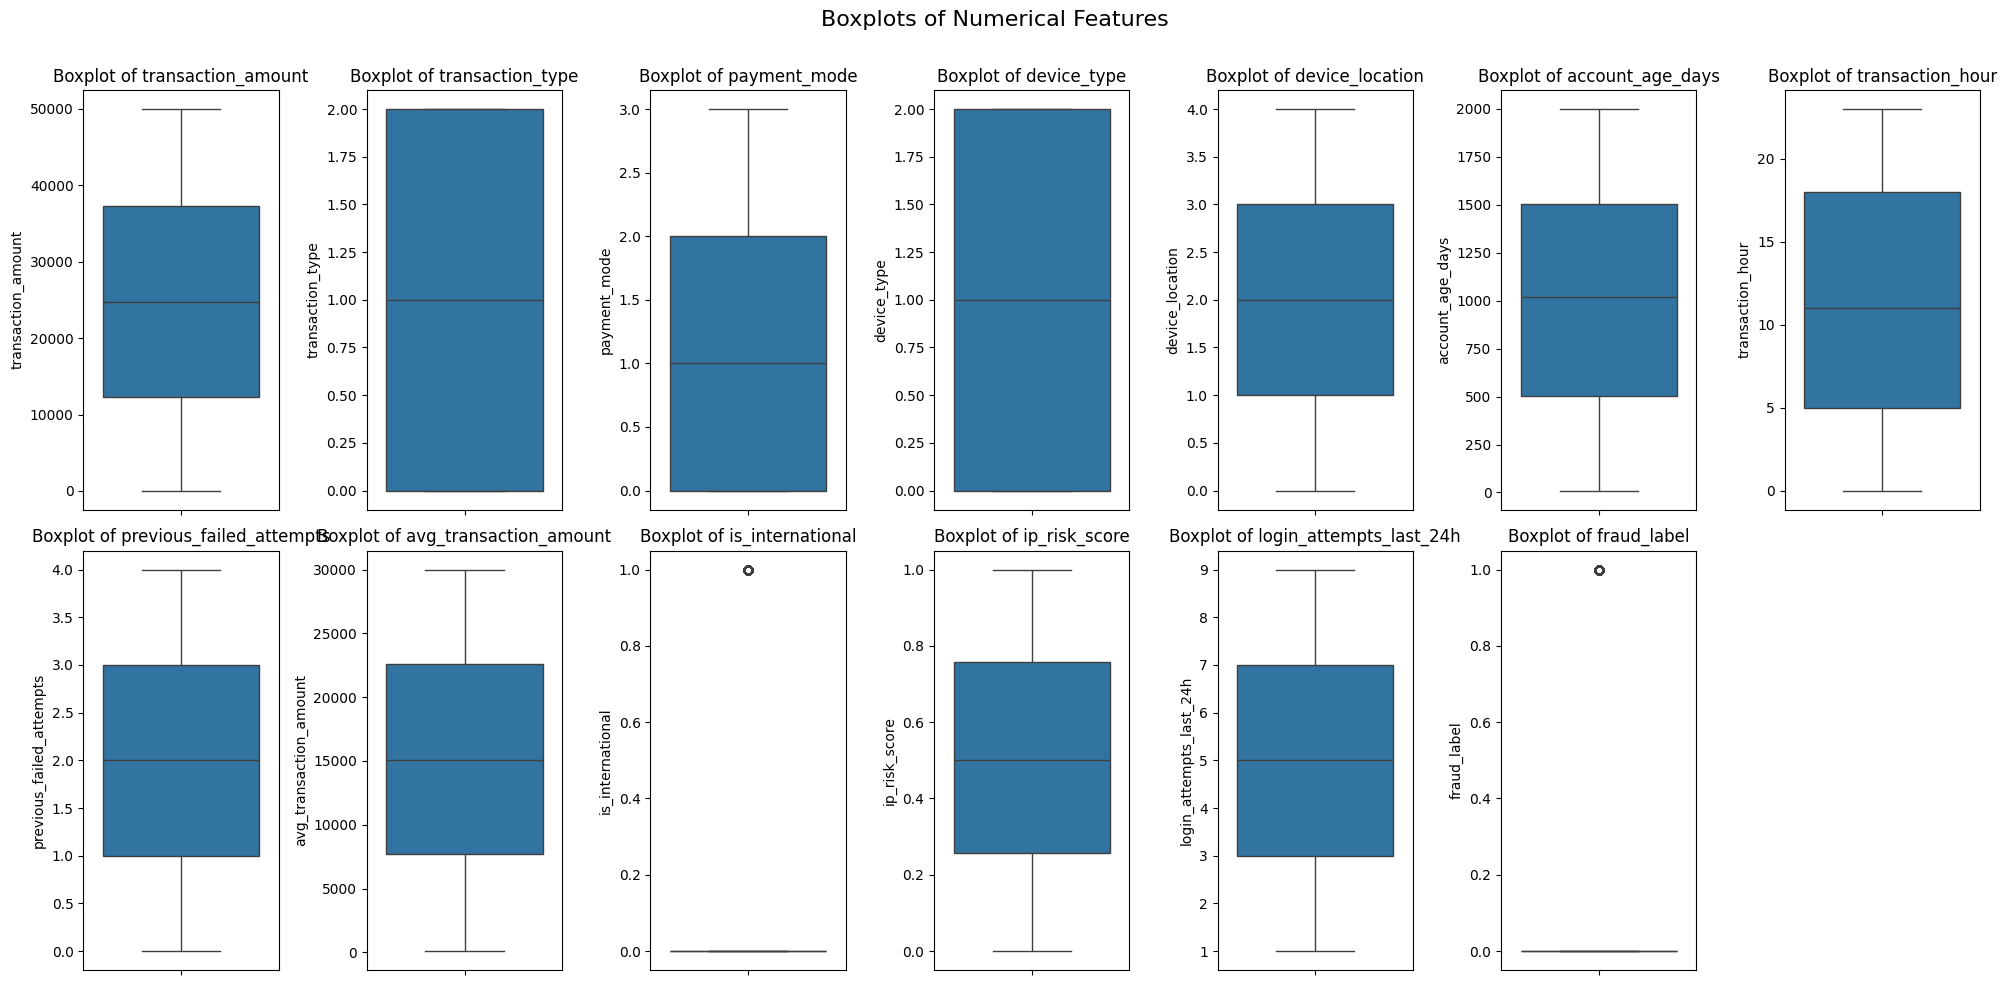

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col != 'target']
plt.figure(figsize=(20, 10))
for idx, num_col in enumerate(num_cols):
    plt.subplot(2, len(num_cols) // 2 + 1, idx + 1)  # Position the subplot
    sns.boxplot(y=df[num_col])  # Plot the boxplot for the current column
    plt.title(f'Boxplot of {num_col}')  # Title for each boxplot

plt.suptitle('Boxplots of Numerical Features', fontsize=16)  # Main title
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the title
plt.show()

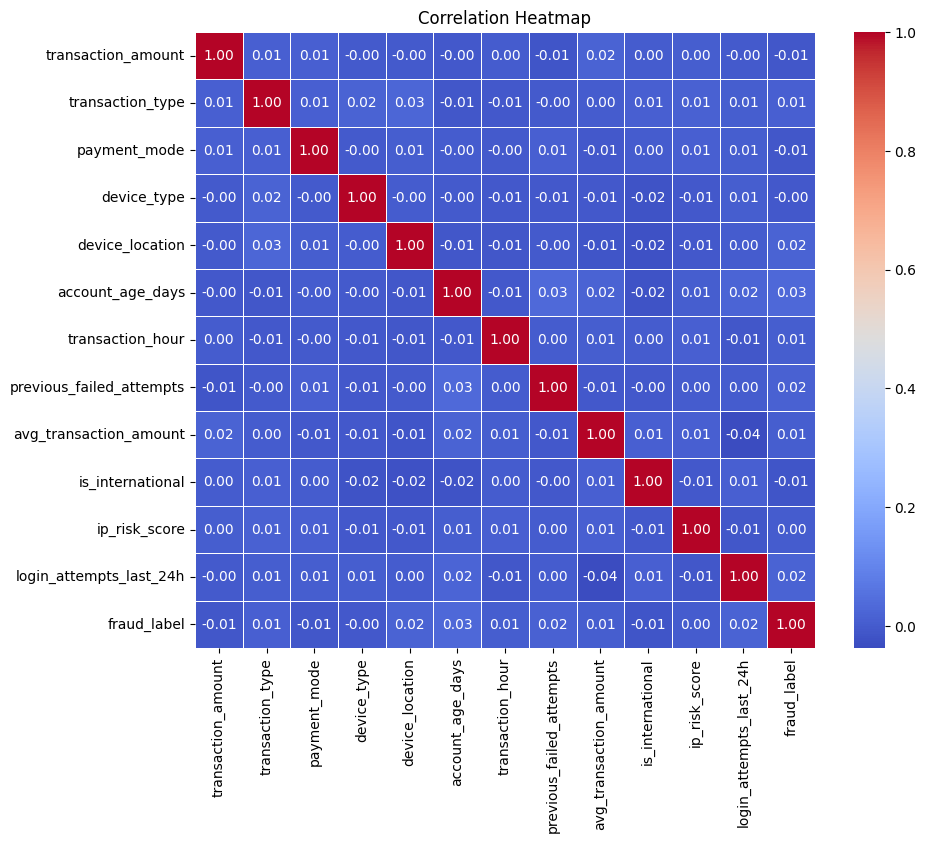

In [14]:
#Multivariate analysis using heat map
# Select numerical columns excluding 'target'
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col != 'target']

# Compute the correlation matrix for numerical columns
corr_matrix = df[num_cols].corr()  # Only use numeric columns for correlation calculation

# Plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



In [15]:
X=df.drop(['transaction_id','user_id','fraud_label'],axis=1)
X

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h
0,18758.28,1,2,1,3,895,14,1,25535.84,0,0.718,4
1,47538.18,0,3,2,3,918,21,0,3955.85,0,0.525,9
2,36613.10,0,0,0,1,1506,8,4,22727.71,0,0.985,9
3,29952.99,0,3,2,1,800,1,3,18095.89,0,0.797,2
4,7843.13,0,2,1,2,301,4,1,9317.49,1,0.468,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3962.99,0,0,1,2,1917,14,0,24820.55,0,0.926,9
7496,3675.11,1,0,1,3,329,0,4,6208.20,0,0.036,5
7497,42523.37,2,1,0,1,67,19,1,27344.69,0,0.149,6
7498,10681.86,2,2,1,3,282,15,2,26586.50,0,0.198,2


In [16]:
y=df["fraud_label"]
y

0       0
1       0
2       0
3       0
4       0
       ..
7495    0
7496    0
7497    0
7498    0
7499    0
Name: fraud_label, Length: 7500, dtype: int64

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
# Initialize scaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [19]:
#!pip install imbalanced-learn

In [20]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution before and after SMOTE
print("Original class distribution:\n", y_train.value_counts())
print("\nResampled class distribution:\n", y_train_smote.value_counts())

Original class distribution:
 fraud_label
0    5608
1     392
Name: count, dtype: int64

Resampled class distribution:
 fraud_label
0    5608
1    5608
Name: count, dtype: int64


In [21]:
lr=LogisticRegression(max_iter=100)
lr.fit(X_train,y_train)

LogisticRegression()

In [22]:
y_pred=lr.predict(X_test)

In [23]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9353333333333333


In [24]:
report=classification_report(y_test,y_pred)
print("Classification Report:",report)

Classification Report:               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.00      0.00      0.00        97

    accuracy                           0.94      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.87      0.94      0.90      1500



In [25]:
lr=LogisticRegression(max_iter=100)
lr.fit(X_train_smote,y_train_smote)

LogisticRegression()

In [26]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([0, 1, 0, ..., 1, 1, 0], shape=(1500,))

In [27]:
print("Logistic Regression Accuracy:",
accuracy_score(y_test,y_pred_lr))

print("Logistic Regression Confusion Matrix:\n",confusion_matrix(y_test,y_pred_lr))
print("Logistic Regression Classification Report:\n",classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.54
Logistic Regression Confusion Matrix:
 [[768 635]
 [ 55  42]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.55      0.69      1403
           1       0.06      0.43      0.11        97

    accuracy                           0.54      1500
   macro avg       0.50      0.49      0.40      1500
weighted avg       0.88      0.54      0.65      1500



In [28]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
y_pred=rf.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [30]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9353333333333333


In [31]:
confusion=confusion_matrix(y_test,y_pred)
confusion

array([[1403,    0],
       [  97,    0]])

In [32]:
classification=classification_report(y_test,y_pred)
print("Classification Report:",classification)

Classification Report:               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.00      0.00      0.00        97

    accuracy                           0.94      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.87      0.94      0.90      1500



In [33]:
knn=KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
y_pred_knn=knn.predict(X_test)
y_pred_knn

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [35]:
print("KNN Accuracy:",
accuracy_score(y_test,y_pred_knn))

print("KNN Confusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("KNN Classification Report:\n",classification_report(y_test,y_pred_knn))

KNN Accuracy: 0.9353333333333333
KNN Confusion Matrix:
 [[1402    1]
 [  96    1]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.50      0.01      0.02        97

    accuracy                           0.94      1500
   macro avg       0.72      0.50      0.49      1500
weighted avg       0.91      0.94      0.91      1500



In [36]:
knn=KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)

KNeighborsClassifier()

In [37]:
y_pred_knn=knn.predict(X_test)
y_pred_knn

array([1, 0, 1, ..., 0, 1, 0], shape=(1500,))

In [38]:
print("KNN Accuracy:",
accuracy_score(y_test,y_pred_knn))

print("KNN Confusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("KNN Classification Report:\n",classification_report(y_test,y_pred_knn))

KNN Accuracy: 0.6753333333333333
KNN Confusion Matrix:
 [[990 413]
 [ 74  23]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.71      0.80      1403
           1       0.05      0.24      0.09        97

    accuracy                           0.68      1500
   macro avg       0.49      0.47      0.44      1500
weighted avg       0.87      0.68      0.76      1500



In [39]:
svm=SVC()
svm.fit(X_train_smote,y_train_smote)

SVC()

In [40]:
y_pred_svm=knn.predict(X_test)
y_pred_svm


array([1, 0, 1, ..., 0, 1, 0], shape=(1500,))

In [41]:
print("SVM Accuracy:",
accuracy_score(y_test,y_pred_svm))

print("SVM Confusion Matrix:\n",confusion_matrix(y_test,y_pred_svm))
print("SVM Classification Report:\n",classification_report(y_test,y_pred_svm))

SVM Accuracy: 0.6753333333333333
SVM Confusion Matrix:
 [[990 413]
 [ 74  23]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.71      0.80      1403
           1       0.05      0.24      0.09        97

    accuracy                           0.68      1500
   macro avg       0.49      0.47      0.44      1500
weighted avg       0.87      0.68      0.76      1500



In [42]:
gb = GradientBoostingClassifier()
gb.fit(X_train_smote,y_train_smote)

GradientBoostingClassifier()

In [43]:
y_pred_gb = gb.predict(X_test)
y_pred_gb

array([1, 1, 1, ..., 1, 1, 1], shape=(1500,))

In [44]:
print("Gradient Boosting Accuracy:",
accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 0.066


In [45]:
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)
y_pred_gb = gb.predict(X_test)
y_pred_gb
print("Gradient Boosting Accuracy:",
accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 0.924


In [46]:
# from sklearn.model_selection import RandomizedSearchCV
# # Define the RandomForest model (initial model, but RandomizedSearchCV will override parameters)
# model_rf = RandomForestClassifier(random_state=0)

# # Define the parameter grid to search
# param_dist = {
#     'n_estimators': [10, 50, 100, 200, 300],  # Number of trees in the forest
#     'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider for the best split
#     'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
#     'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
#     'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
#     'bootstrap': [True, False],  # Whether bootstrap samples are used when building trees
#     'criterion': ['gini', 'entropy']  # Split criterion
# }

# # Set up RandomizedSearchCV
# random_search = RandomizedSearchCV(estimator=model_rf,
#                                    param_distributions=param_dist,
#                                    n_iter=100,  # Number of random combinations to try
#                                    cv=5,  # Cross-validation splits
#                                    verbose=2,  # To show progress
#                                    random_state=42,  # Set seed for reproducibility
#                                    n_jobs=-1)  # Use all available CPU cores

# # Fit RandomizedSearchCV to the data (X_train_smote and y_train_smote)
# random_search.fit(X_train, y_train)

# # Best hyperparameters found
# print("Best hyperparameters found: ", random_search.best_params_)

# # Get the best model found by RandomizedSearchCV
# best_rf_model = random_search.best_estimator_

# # Make predictions using the best model on the test data
# y_pred_rf = best_rf_model.predict(X_test)

# # Calculate accuracy
# accuracy_rf = accuracy_score(y_test, y_pred_rf)

# # Print the accuracy
# print("Accuracy with RandomizedSearchCV: ", accuracy_rf)

In [47]:
new_transaction={'transaction_amount':15246.9,'transaction_type':0,'payment_mode':2,'device_type':1,'device_location':3,'account_age_days':1978,'transaction_hour':4,'previous_failed_attempts':1,'avg_transaction_amount':28448.77,'is_international':0,'ip_risk_score':0.58,'login_attempts_last_24h':2}
new_df=pd.DataFrame([new_transaction])
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])
                 

Prediction(0=Not Fraud,1=Fraud): 0


In [48]:
new_transaction={'transaction_amount':11683.45,'transaction_type':1,'payment_mode':1,'device_type':1,'device_location':1,'account_age_days':1843,'transaction_hour':10,'previous_failed_attempts':3,'avg_transaction_amount':6090.84,'is_international':0,'ip_risk_score':0.002,'login_attempts_last_24h':8}
new_df=pd.DataFrame([new_transaction])
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])
                 

Prediction(0=Not Fraud,1=Fraud): 1


In [49]:
new_transaction={'transaction_amount':80000,'transaction_type':3,'payment_mode':4,'device_type':2,'device_location':4,'account_age_days':5,'transaction_hour':2,'previous_failed_attempts':8,'avg_transaction_amount':500,'is_international':1,'ip_risk_score':0.92,'login_attempts_last_24h':15}
new_df=pd.DataFrame([new_transaction])
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])

Prediction(0=Not Fraud,1=Fraud): 1


In [50]:
new_transaction={'transaction_amount':1200,'transaction_type':1,'payment_mode':1,'device_type':0,'device_location':1,'account_age_days':1500,'transaction_hour':14,'previous_failed_attempts':0,'avg_transaction_amount':1100,'is_international':0,'ip_risk_score':0,'login_attempts_last_24h':1}
new_df=pd.DataFrame([new_transaction])
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])

Prediction(0=Not Fraud,1=Fraud): 0
